<a href="https://colab.research.google.com/github/kethanprem/optimizer-visualizer/blob/main/Optimizer_Visualiser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

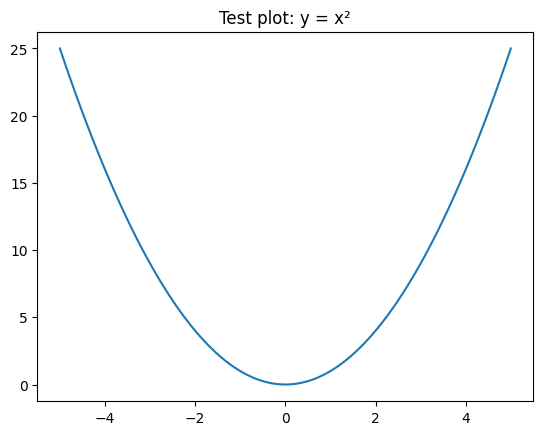

In [1]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-5, 5, 100)
plt.plot(x, x ** 2)
plt.title("Test plot: y = x²")
plt.show()

In [2]:

def gradient_descent(grad, start, learning_rate, steps):
    x = np.array(start, dtype=float)
    path = [x.copy()]
    for _ in range(steps):
        x = x - learning_rate * grad(x)
        path.append(x.copy())
    return np.array(path)

def momentum(grad, start, learning_rate, beta, steps):
    x = np.array(start, dtype=float)
    v = np.zeros_like(x)
    path = [x.copy()]
    for _ in range(steps):
        v = beta * v - learning_rate * grad(x)
        x = x + v
        path.append(x.copy())
    return np.array(path)

def adam(grad, start, learning_rate, steps, beta1=0.9, beta2=0.999, eps=1e-8):
    x = np.array(start, dtype=float)
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    path = [x.copy()]
    for t in range(1, steps + 1):
        g = grad(x)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g ** 2
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)
        x = x - learning_rate * m_hat / (np.sqrt(v_hat) + eps)
        path.append(x.copy())
    return np.array(path)


SECTION 2: first 5 positions: [3.     2.4    1.92   1.536  1.2288]
SECTION 2: final x: 0.03458764513820541


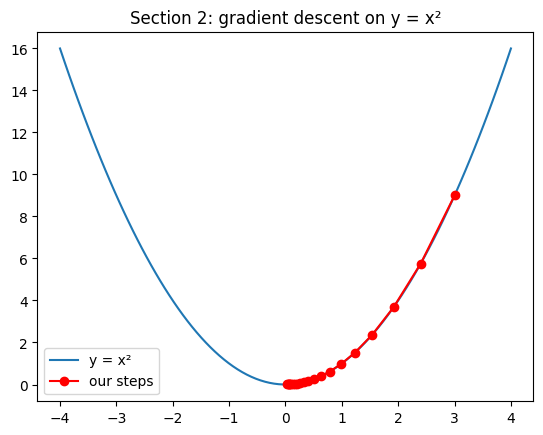

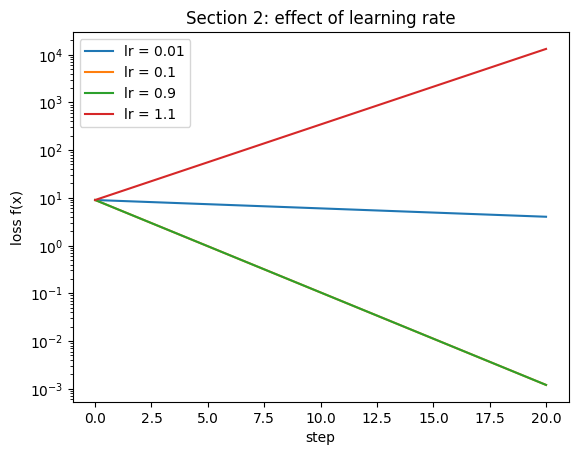

In [3]:

def f1(x):
    return x ** 2

def slope1(x):
    return 2 * x

path1 = gradient_descent(slope1, start=3.0, learning_rate=0.1, steps=20)
print("SECTION 2: first 5 positions:", path1[:5].ravel())
print("SECTION 2: final x:", path1[-1])

xs1 = np.linspace(-4, 4, 100)
plt.plot(xs1, f1(xs1), label="y = x²")
plt.plot(path1, f1(path1), "ro-", label="our steps")
plt.legend()
plt.title("Section 2: gradient descent on y = x²")
plt.show()

# effect of the learning rate
for lr in [0.01, 0.1, 0.9, 1.1]:
    p = gradient_descent(slope1, start=3.0, learning_rate=lr, steps=20)
    plt.plot(f1(p), label=f"lr = {lr}")
plt.xlabel("step")
plt.ylabel("loss f(x)")
plt.yscale("log")
plt.legend()
plt.title("Section 2: effect of learning rate")
plt.show()

SECTION 3: final point: [0.01038665 0.00247588]


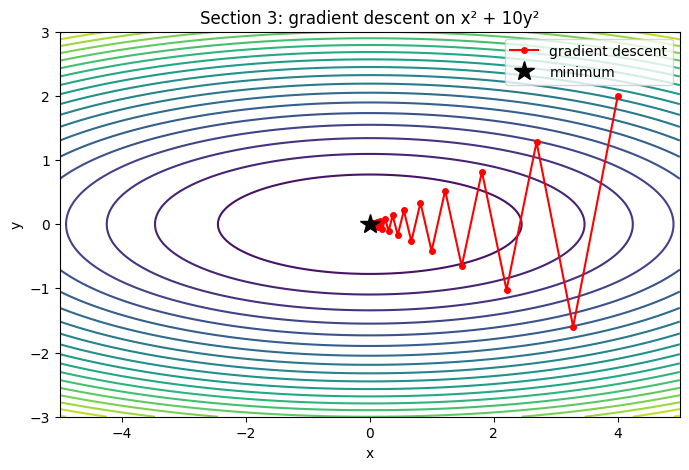

In [4]:

def f2(p):
    return p[0] ** 2 + 10 * p[1] ** 2

def grad2(p):
    return np.array([2 * p[0], 20 * p[1]])

path2 = gradient_descent(grad2, start=[4.0, 2.0], learning_rate=0.09, steps=30)
print("SECTION 3: final point:", path2[-1])

gx = np.linspace(-5, 5, 200)
gy = np.linspace(-3, 3, 200)
GX, GY = np.meshgrid(gx, gy)
GZ = GX ** 2 + 10 * GY ** 2

plt.figure(figsize=(8, 5))
plt.contour(GX, GY, GZ, levels=20)
plt.plot(path2[:, 0], path2[:, 1], "ro-", markersize=4, label="gradient descent")
plt.plot(0, 0, "k*", markersize=15, label="minimum")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Section 3: gradient descent on x² + 10y²")
plt.show()


SECTION 4: Method                  final x      final y     final loss
           Gradient descent       0.391349     0.001797     0.15331556
           Momentum               0.000001     0.000001     0.00000000
           Adam                   0.085855    -0.034597     0.06721912


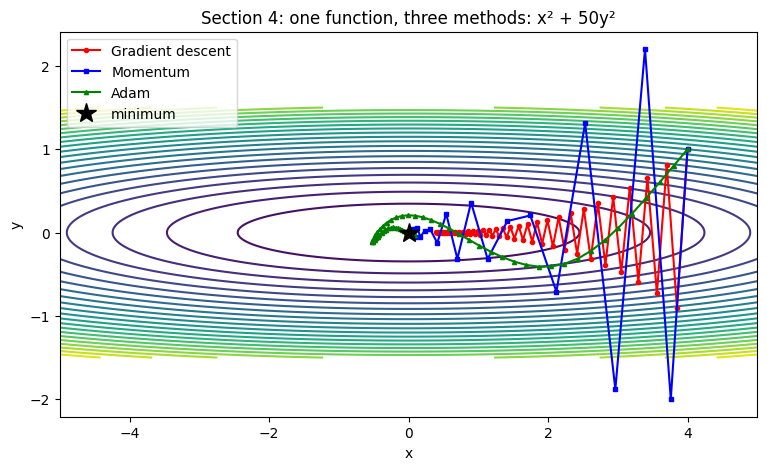

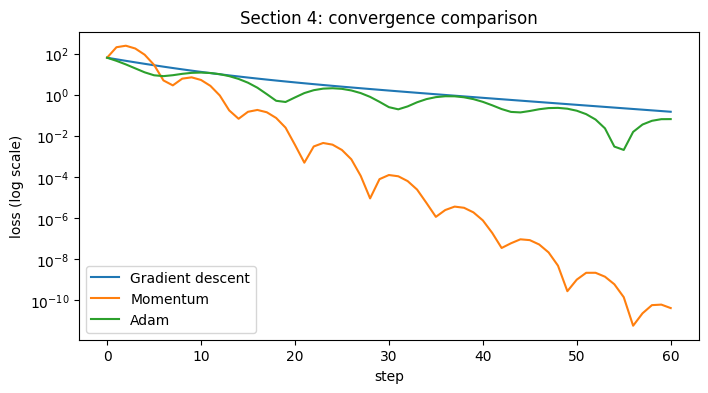

In [5]:

def f3(p):
    return p[0] ** 2 + 50 * p[1] ** 2

def grad3(p):
    return np.array([2 * p[0], 100 * p[1]])

start3 = [4.0, 1.0]
results = {
    "Gradient descent": gradient_descent(grad3, start3, learning_rate=0.019, steps=60),
    "Momentum":         momentum(grad3, start3, learning_rate=0.03, beta=0.6, steps=60),
    "Adam":             adam(grad3, start3, learning_rate=0.2, steps=60),
}

print(f"\nSECTION 4: {'Method':18s} {'final x':>12s} {'final y':>12s} {'final loss':>14s}")
for name, p in results.items():
    print(f"           {name:18s} {p[-1][0]:12.6f} {p[-1][1]:12.6f} {f3(p[-1]):14.8f}")

vx = np.linspace(-5, 5, 200)
vy = np.linspace(-1.5, 1.5, 200)
VX, VY = np.meshgrid(vx, vy)
VZ = VX ** 2 + 50 * VY ** 2
styles = {"Gradient descent": "ro-", "Momentum": "bs-", "Adam": "g^-"}

plt.figure(figsize=(9, 5))
plt.contour(VX, VY, VZ, levels=25)
for name, p in results.items():
    plt.plot(p[:, 0], p[:, 1], styles[name], markersize=3, label=name)
plt.plot(0, 0, "k*", markersize=15, label="minimum")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Section 4: one function, three methods: x² + 50y²")
plt.show()

plt.figure(figsize=(8, 4))
for name, p in results.items():
    plt.plot([f3(q) for q in p], label=name)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("loss (log scale)")
plt.legend()
plt.title("Section 4: convergence comparison")
plt.show()


SECTION 5:      lr   gradient descent     momentum         adam
             0.001           1.07e+01     5.92e+00     5.59e+01
             0.003           4.80e+00     7.60e-01     3.94e+01
              0.01           2.81e-01     2.54e-04     1.18e+01
              0.03           1.00e+06     1.76e-20     2.18e+00
               0.1           1.00e+06     1.00e+06     8.90e-04
               0.3           1.00e+06     1.00e+06     1.67e-04
               1.0           1.00e+06     1.00e+06     2.57e-04


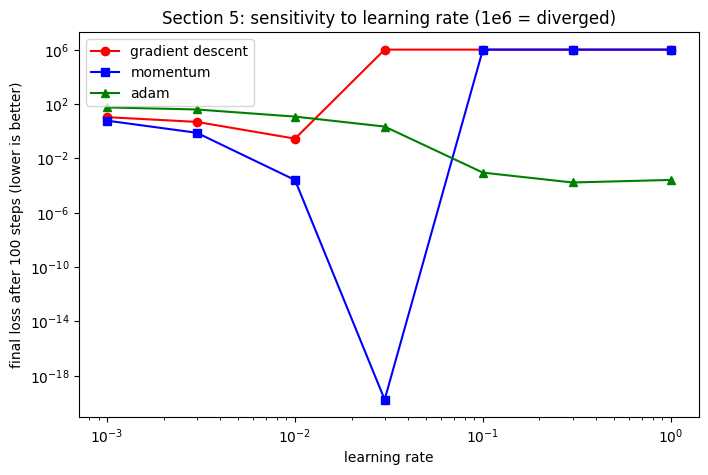

In [6]:

def final_loss(path):
    loss = f3(path[-1])
    if not np.isfinite(loss) or loss > 1e6:
        return 1e6          # "blew up" is shown as a very large loss
    return loss

rates = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]
gd_losses, mom_losses, adam_losses = [], [], []

with np.errstate(all="ignore"):
    for lr in rates:
        gd_losses.append(final_loss(gradient_descent(grad3, start3, lr, 100)))
        mom_losses.append(final_loss(momentum(grad3, start3, lr, 0.6, 100)))
        adam_losses.append(final_loss(adam(grad3, start3, lr, 100)))

print(f"\nSECTION 5: {'lr':>7} {'gradient descent':>18} {'momentum':>12} {'adam':>12}")
for lr, a, b, c in zip(rates, gd_losses, mom_losses, adam_losses):
    print(f"           {lr:>7} {a:>18.2e} {b:>12.2e} {c:>12.2e}")

plt.figure(figsize=(8, 5))
plt.plot(rates, gd_losses, "ro-", label="gradient descent")
plt.plot(rates, mom_losses, "bs-", label="momentum")
plt.plot(rates, adam_losses, "g^-", label="adam")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("learning rate")
plt.ylabel("final loss after 100 steps (lower is better)")
plt.title("Section 5: sensitivity to learning rate (1e6 = diverged)")
plt.legend()
plt.show()


SECTION 6: true line used to make data:  w = 3.000, b = 5.000
           exact least squares answer:   w = 2.987, b = 5.444
           gradient descent              w = 3.041, b = 5.102, loss = 4.0015
           momentum                      w = 2.987, b = 5.444, loss = 3.9698
           adam                          w = 3.007, b = 5.323, loss = 3.9738


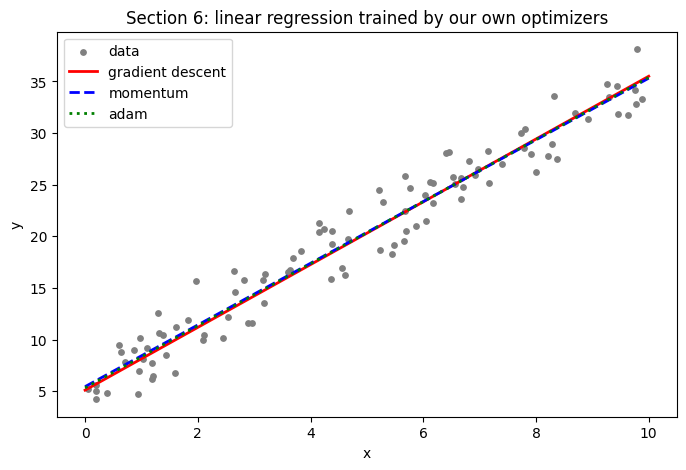

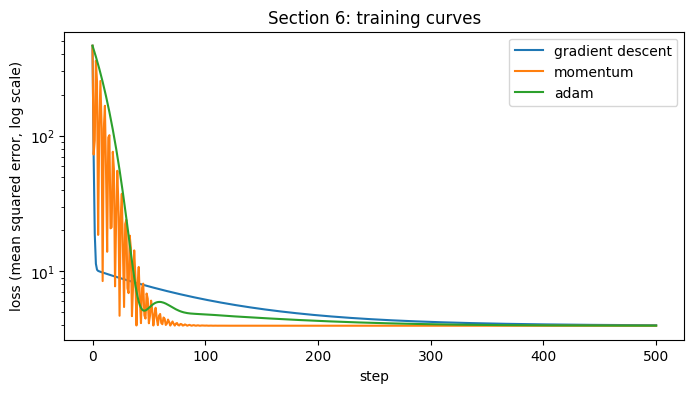

In [7]:

np.random.seed(0)
Xd = np.random.uniform(0, 10, 100)
yd = 3 * Xd + 5 + np.random.normal(0, 2, 100)

def reg_loss(p):
    w, b = p
    return np.mean((w * Xd + b - yd) ** 2)

def reg_grad(p):
    w, b = p
    err = w * Xd + b - yd
    return np.array([2 * np.mean(err * Xd), 2 * np.mean(err)])

start6 = [0.0, 0.0]
reg_paths = {
    "gradient descent": gradient_descent(reg_grad, start6, learning_rate=0.01, steps=500),
    "momentum":         momentum(reg_grad, start6, learning_rate=0.01, beta=0.9, steps=500),
    "adam":             adam(reg_grad, start6, learning_rate=0.1, steps=500),
}

best = np.polyfit(Xd, yd, 1)
print("\nSECTION 6: true line used to make data:  w = 3.000, b = 5.000")
print(f"           exact least squares answer:   w = {best[0]:.3f}, b = {best[1]:.3f}")
for name, p in reg_paths.items():
    print(f"           {name:17s}             w = {p[-1][0]:.3f}, b = {p[-1][1]:.3f}, loss = {reg_loss(p[-1]):.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(Xd, yd, s=15, color="gray", label="data")
lx = np.linspace(0, 10, 100)
line_styles = {"gradient descent": "r-", "momentum": "b--", "adam": "g:"}
for name, p in reg_paths.items():
    plt.plot(lx, p[-1][0] * lx + p[-1][1], line_styles[name], linewidth=2, label=name)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Section 6: linear regression trained by our own optimizers")
plt.show()

plt.figure(figsize=(8, 4))
for name, p in reg_paths.items():
    plt.plot([reg_loss(q) for q in p], label=name)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("loss (mean squared error, log scale)")
plt.legend()
plt.title("Section 6: training curves")
plt.show()